# **K-means实现手写数字聚类**

## **实验目标**

通过本案例的学习和课后作业的练习：

1. 通过代码的实现，帮助大家快速理解机器学习整个流程；
2. 能够使用SKlearn实现K-means算法。


## **案例内容介绍**

**概述**

K-means聚类算法也称k均值聚类算法，是集简单和经典于一身的基于距离的聚类算法。它采用距离作为相似性的评价指标，即认为两个对象的距离越近，其相似度就越大。该算法认为类簇是由距离靠近的对象组成的，因此把得到紧凑且独立的簇作为最终目标。

**基本思想**

K-means算法的基本思想是：以空间中k个点为中心进行聚类，对最靠近他们的对象归类。通过迭代的方法，逐次更新各聚类中心的值，直至得到最好的聚类结果。

**实现步骤**

假设要把样本集分为k个类别，算法描述如下：

　　（1）适当选择k个类的初始中心，最初一般为随机选取；
  
　　（2）在每次迭代中，对任意一个样本，分别求其到k个中心的欧式距离，将该样本归到距离最短的中心所在的类；
  
　　（3）利用均值方法更新该k个类的中心的值；
  
　　（4）对于所有的k个聚类中心，重复（2）（3），类的中心值的移动距离满足一定条件时，则迭代结束，完成分类。
  
**步骤图解**

![kmeans_img](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com/course/hwc_edu/machine_learning/datasets/k-means_data/k-means.png)

本案例推荐的理论学习视频：

- [《AI技术领域课程--机器学习》 K-means ](https://education.huaweicloud.com/courses/course-v1:HuaweiX+CBUCNXE086+Self-paced/courseware/986b8df89d9841f3bc76ddb8b1b9cfa8/3c225550b14a4279b4878d711bbd036c/)  

## **注意事项**

1. 如果您是第一次使用 JupyterLab，请查看[《ModelArts JupyterLab使用指导》](https://support.huaweicloud.com/devtool-modelarts/devtool-modelarts_0012.html)了解使用方法；

2. 如果您在使用 JupyterLab 过程中碰到报错，请参考[《ModelArts JupyterLab常见问题解决办法》](https://support.huaweicloud.com/modelarts_faq/modelarts_05_0185.html)尝试解决问题。

## **实验步骤**

### 1、读取数据

In [1]:
# 导入使用到的模块
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import scale

from sklearn.model_selection import train_test_split
from sklearn import cluster

# 导入手写数字图片数据，digits.data,digits.images, digits.target
digits = load_digits()
print(digits.images.shape)
print(digits.images[0])
print(digits.data.shape)
print(digits.data[0])

(1797, 8, 8)

[[ 0.  0.  5. 13.  9.  1.  0.  0.]

 [ 0.  0. 13. 15. 10. 15.  5.  0.]

 [ 0.  3. 15.  2.  0. 11.  8.  0.]

 [ 0.  4. 12.  0.  0.  8.  8.  0.]

 [ 0.  5.  8.  0.  0.  9.  8.  0.]

 [ 0.  4. 11.  0.  1. 12.  7.  0.]

 [ 0.  2. 14.  5. 10. 12.  0.  0.]

 [ 0.  0.  6. 13. 10.  0.  0.  0.]]

(1797, 64)

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.

 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.

  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.

  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


### 2、数据预处理

In [2]:
# 对图片数据进行预处理,将数据转化为标准正态分布（均值为0，方差为1）
data = scale(digits.data)
print(data.shape)
print(data[0])

(1797, 64)

[ 0.         -0.33501649 -0.04308102  0.27407152 -0.66447751 -0.84412939

 -0.40972392 -0.12502292 -0.05907756 -0.62400926  0.4829745   0.75962245

 -0.05842586  1.12772113  0.87958306 -0.13043338 -0.04462507  0.11144272

  0.89588044 -0.86066632 -1.14964846  0.51547187  1.90596347 -0.11422184

 -0.03337973  0.48648928  0.46988512 -1.49990136 -1.61406277  0.07639777

  1.54181413 -0.04723238  0.          0.76465553  0.05263019 -1.44763006

 -1.73666443  0.04361588  1.43955804  0.         -0.06134367  0.8105536

  0.63011714 -1.12245711 -1.06623158  0.66096475  0.81845076 -0.08874162

 -0.03543326  0.74211893  1.15065212 -0.86867056  0.11012973  0.53761116

 -0.75743581 -0.20978513 -0.02359646 -0.29908135  0.08671869  0.20829258

 -0.36677122 -1.14664746 -0.5056698  -0.19600752]


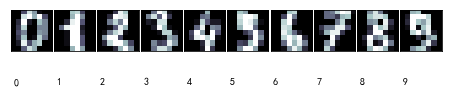

In [3]:
# 定义打印手写数字图片函数
#    images：图像数据
#    y：标签数据
#    max_n：最多打印图像数量
def print_digits(images, y, max_n=10):
    # set up the figure size in inches
    fig = plt.figure(figsize=(12, 12))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
    i = 0
    while i < max_n and i < images.shape[0]:
        # plot the images in a matrix of 20x20
        p = fig.add_subplot(20, 20, i + 1, xticks=[], yticks=[])
        p.imshow(images[i], cmap=plt.cm.bone)
        # label the image with the target value
        p.text(0, 14, str(y[i]))
        i = i + 1


# 打印通过load_digits()获取的数据集中的10张图像
print_digits(digits.images, digits.target, max_n=10)

### 3、kmeans模型训练

In [4]:
# 使用train_test_split切分训练数据和测试数据
X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(data, digits.target, digits.images,
                                                                               test_size=0.25, random_state=42)

n_samples, n_features = X_train.shape  # n_samples:训练样本大小；n_features：特征维度
n_digits = len(np.unique(y_train))  # n_digits：原始类别个数
labels = y_train  # labels：原始标签

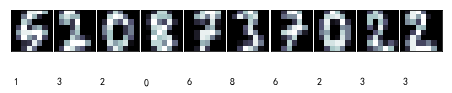

In [5]:
# 使用cluster.KMeans对训练数据进行聚类分析
#     init：簇中心初始值的选择方式
#     n_clusters：聚类个数
#     random_state：整形或 numpy.RandomState 类型，可选用于初始化质心的生成器（generator）
clf = cluster.KMeans(init='k-means++', n_clusters=10, random_state=42)
clf.fit(X_train)  # clf.labels_对应每个样本聚类之后的类别标识
# 打印聚类之后的手写数字图像
print_digits(images_train, clf.labels_, max_n=10)

### 4、kmeans模型结果展示

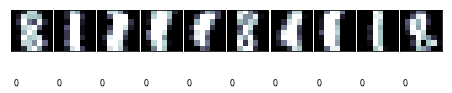

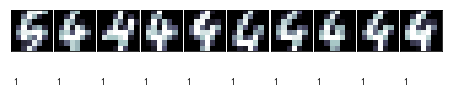

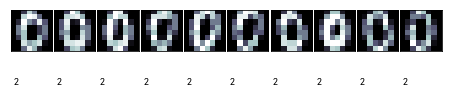

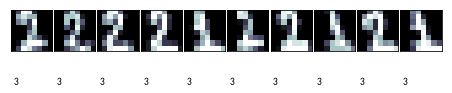

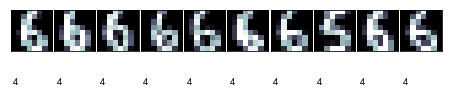

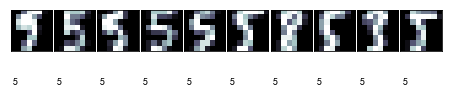

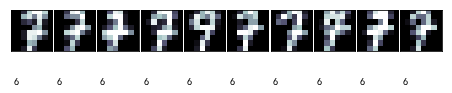

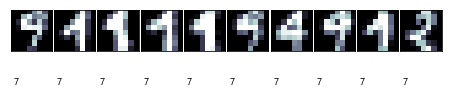

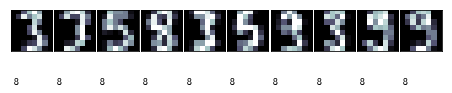

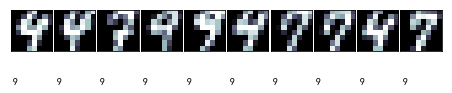

In [6]:
# 定义打印聚类结果的函数
#     images：图像数据
#     label：聚类结果标识
#     cluster_number：聚类结果标识号码
def print_cluster(images, label, cluster_number):
    images = images[label == cluster_number]
    label = label[label == cluster_number]
    print_digits(images, label, max_n=10)


for i in range(10):
    print_cluster(images_train, clf.labels_, i)

## 小结

通过本实验可以看到kmeans算法将视觉上相似的图像聚类到了一起，该结果和实际的手写数字类别划分之间存在一定的误差，例如将9、7的数字图像聚成一类，3、5、8的手写数字聚成一类等等。